In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [70]:
df = pd.read_csv('amazon_sales_data 2025.csv')

In [71]:
df.head()

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending


In [72]:
#The first thing you must do before doing the data analyis is formulate the business
# questions you want to answer and the metrics(KPl) 
# Which product and categories are highest revenue ?

In [73]:


#Step 1 : Data Cleaning and Validation¶
#Check for and handel missing or invalid values
#Ensure that the data types are correct (data, numerics , categories)
#Remove duplicates or test for outliers

In [74]:

#Overview 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           250 non-null    object
 1   Date               250 non-null    object
 2   Product            250 non-null    object
 3   Category           250 non-null    object
 4   Price              250 non-null    int64 
 5   Quantity           250 non-null    int64 
 6   Total Sales        250 non-null    int64 
 7   Customer Name      250 non-null    object
 8   Customer Location  250 non-null    object
 9   Payment Method     250 non-null    object
 10  Status             250 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.6+ KB


In [75]:
# Form the info what we can conclude is that the Date is not in the right Dtype so 
# we changed that it date datatype


In [76]:
print(df.memory_usage(deep=True))

Index                  132
Order ID             14000
Date                 14250
Product              14553
Category             14809
Price                 2000
Quantity              2000
Total Sales           2000
Customer Name        15036
Customer Location    14065
Payment Method       14522
Status               14330
dtype: int64


In [77]:
df["Date"] = pd.to_datetime(df["Date"], format = "%d-%m-%y")
df["Price"] =df["Price"].astype("int32")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           250 non-null    object        
 1   Date               250 non-null    datetime64[ns]
 2   Product            250 non-null    object        
 3   Category           250 non-null    object        
 4   Price              250 non-null    int32         
 5   Quantity           250 non-null    int64         
 6   Total Sales        250 non-null    int64         
 7   Customer Name      250 non-null    object        
 8   Customer Location  250 non-null    object        
 9   Payment Method     250 non-null    object        
 10  Status             250 non-null    object        
dtypes: datetime64[ns](1), int32(1), int64(2), object(7)
memory usage: 20.6+ KB


In [78]:
# We are converting int64 to int32 as it 
# requires less momory and helps in optimization.
# A signed 32-bit integers uses 1 bit for the sign and remaining 31 bits for storing numbers
print(df.memory_usage(deep=True))


Index                  132
Order ID             14000
Date                  2000
Product              14553
Category             14809
Price                 1000
Quantity              2000
Total Sales           2000
Customer Name        15036
Customer Location    14065
Payment Method       14522
Status               14330
dtype: int64


In [79]:
df.isna().sum()# Checkig is there are any null values in the datas

Order ID             0
Date                 0
Product              0
Category             0
Price                0
Quantity             0
Total Sales          0
Customer Name        0
Customer Location    0
Payment Method       0
Status               0
dtype: int64

In [80]:
df["Customer Location"].unique()
# It gives all the unique value of that columns

array(['New York', 'San Francisco', 'Denver', 'Dallas', 'Houston',
       'Miami', 'Boston', 'Seattle', 'Los Angeles', 'Chicago'],
      dtype=object)

In [81]:
df["Customer Location"].value_counts()

Customer Location
Houston          32
Miami            31
Dallas           29
New York         26
Denver           26
Boston           26
Seattle          22
Chicago          22
San Francisco    19
Los Angeles      17
Name: count, dtype: int64

In [82]:
# As the price can also be in float value convert teh int into float
df["Price"] = df["Price"].astype(float)

In [83]:
# Handeling the duplicates:: droping if there are same data more then once
df.drop_duplicates(subset="Order ID",inplace = True)

In [84]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           250 non-null    object        
 1   Date               250 non-null    datetime64[ns]
 2   Product            250 non-null    object        
 3   Category           250 non-null    object        
 4   Price              250 non-null    float64       
 5   Quantity           250 non-null    int64         
 6   Total Sales        250 non-null    int64         
 7   Customer Name      250 non-null    object        
 8   Customer Location  250 non-null    object        
 9   Payment Method     250 non-null    object        
 10  Status             250 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 21.6+ KB


In [186]:
df[df["Total Sales"]<=20]

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Year,Month,Day
5,ORD0006,2025-03-14,T-Shirt,Clothing,20.0,1,20,John Doe,Dallas,Credit Card,Pending,2025,March,Friday
16,ORD0017,2025-04-01,T-Shirt,Clothing,20.0,1,20,Emma Clark,New York,Amazon Pay,Completed,2025,April,Tuesday
22,ORD0023,2025-02-23,Book,Books,15.0,1,15,Emma Clark,Houston,Credit Card,Pending,2025,February,Sunday
26,ORD0027,2025-02-07,T-Shirt,Clothing,20.0,1,20,Daniel Harris,New York,Amazon Pay,Pending,2025,February,Friday
32,ORD0033,2025-02-04,Book,Books,15.0,1,15,Olivia Wilson,New York,Debit Card,Cancelled,2025,February,Tuesday
40,ORD0041,2025-02-20,Book,Books,15.0,1,15,Jane Smith,Miami,Credit Card,Cancelled,2025,February,Thursday
50,ORD0051,2025-02-19,Book,Books,15.0,1,15,Emma Clark,Houston,Gift Card,Cancelled,2025,February,Wednesday
69,ORD0070,2025-03-10,Book,Books,15.0,1,15,Emily Johnson,Boston,Credit Card,Completed,2025,March,Monday
116,ORD0117,2025-02-27,T-Shirt,Clothing,20.0,1,20,Daniel Harris,New York,Credit Card,Completed,2025,February,Thursday
123,ORD0124,2025-02-10,Book,Books,15.0,1,15,Emma Clark,Seattle,Gift Card,Pending,2025,February,Monday


In [85]:
# Extracting the year , months, weekday from the data
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name() # Extracting the month name
df["Day"] = df["Date"].dt.day_name()

In [86]:
#Exploratory Data Analysis¶
#Here we will examine single variable distribution : price , quantity ,total sales and spot skew , outliers , understand typical order size

In [87]:
df["Total Sales"].describe() 
# It describes the statistics of particular column.

count     250.000000
mean      975.380000
std      1252.112254
min        15.000000
25%       100.000000
50%       400.000000
75%      1500.000000
max      6000.000000
Name: Total Sales, dtype: float64

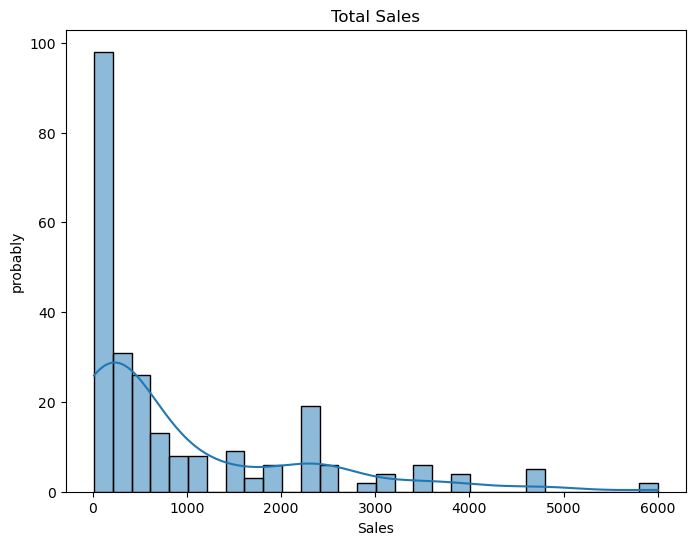

In [177]:
plt.figure(figsize=(8,6))
sns.histplot(df['Total Sales'],kde=True,bins=30)
plt.title('Total Sales')
plt.xlabel('Sales')
plt.ylabel('probably')
plt.show()

Text(0.5, 0, 'Price')

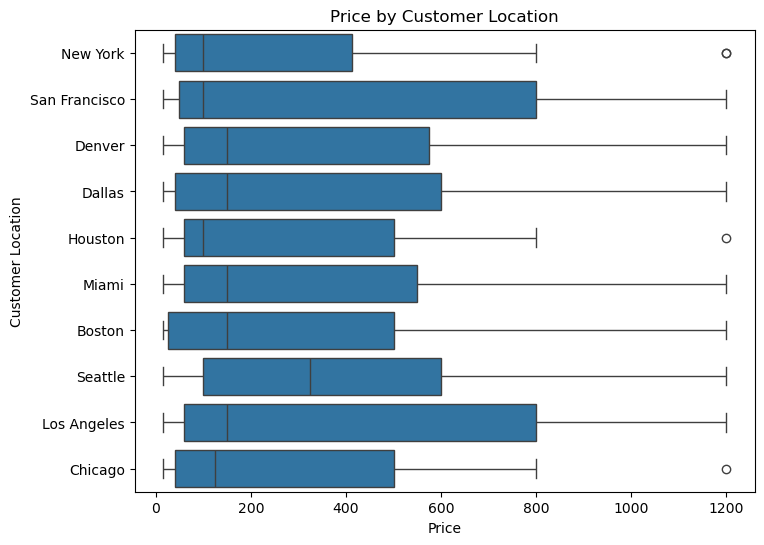

In [89]:
# Drawing the boxplot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.boxplot(x='Price', y='Customer Location',data=df)
plt.title('Price by Customer Location')
plt.xlabel('Price')
# by helps us to group the data by category

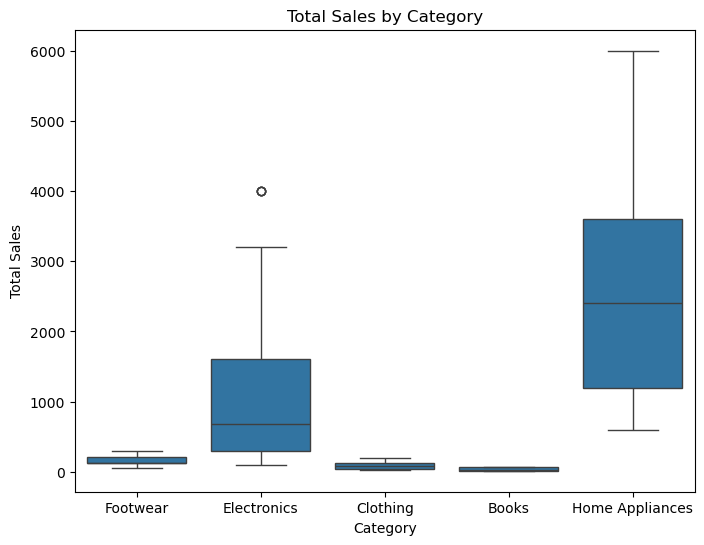

In [179]:
# Finding the total sales based on different Categories
plt.figure(figsize=(8,6))
sns.boxplot(x='Category', y='Total Sales',data=df)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

In [91]:
df["Category"].value_counts()


Category
Electronics        118
Clothing            40
Home Appliances     40
Footwear            27
Books               25
Name: count, dtype: int64

In [129]:
df["Product"].value_counts()


Product
Smartphone         35
Smartwatch         34
Running Shoes      27
Headphones         25
Book               25
Laptop             24
Refrigerator       24
T-Shirt            20
Jeans              20
Washing Machine    16
Name: count, dtype: int64

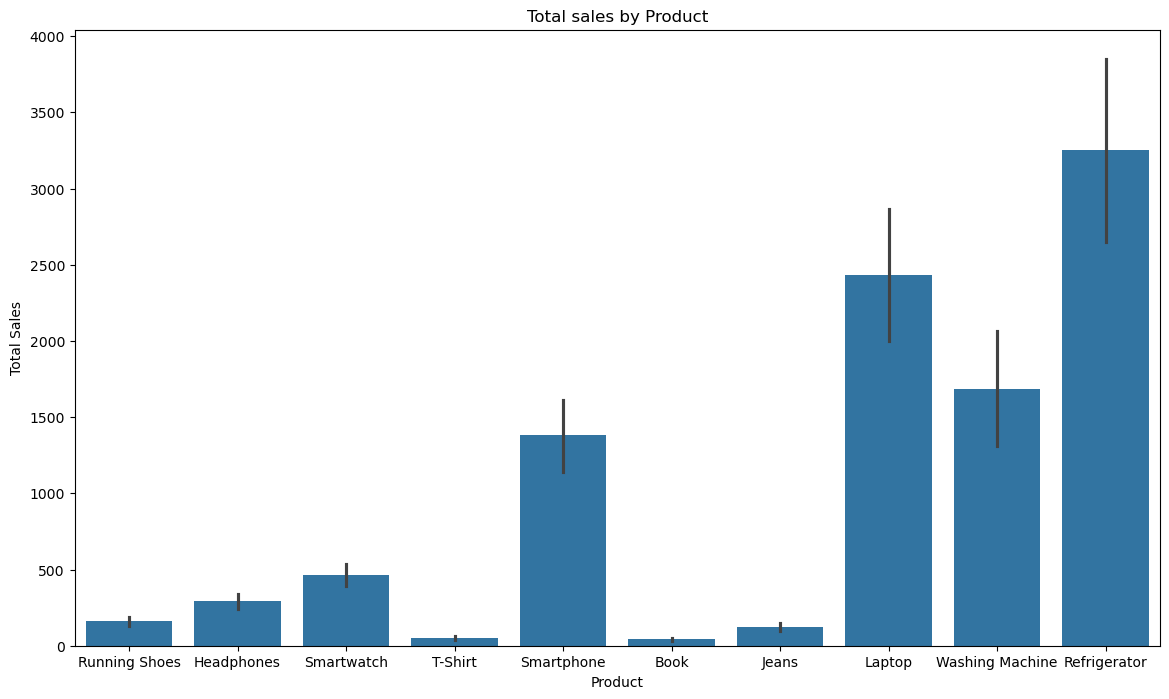

In [144]:
plt.figure(figsize=(14,8))
sns.barplot(x='Product',y='Total Sales',data=df)
plt.title('Total sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.show()
# This will give  us the barh plot of  the total sales which is grouped by according to the product so it draws the box plot for each and every product categoreis

In [99]:
df["Day"].value_counts()


Day
Monday       42
Sunday       40
Wednesday    37
Thursday     36
Friday       34
Tuesday      33
Saturday     28
Name: count, dtype: int64

In [100]:
#Grouping of the data
# Grouped according to the Location


In [101]:
grouped_location = df.groupby("Customer Location")["Total Sales"].sum().sort_values(ascending = False)
print(grouped_location)
# This gives in which location was there more amount of sell

Customer Location
Miami            31700
Denver           29785
Houston          28390
Dallas           27145
Seattle          26890
Boston           26170
Chicago          20810
New York         18940
Los Angeles      17820
San Francisco    16195
Name: Total Sales, dtype: int64


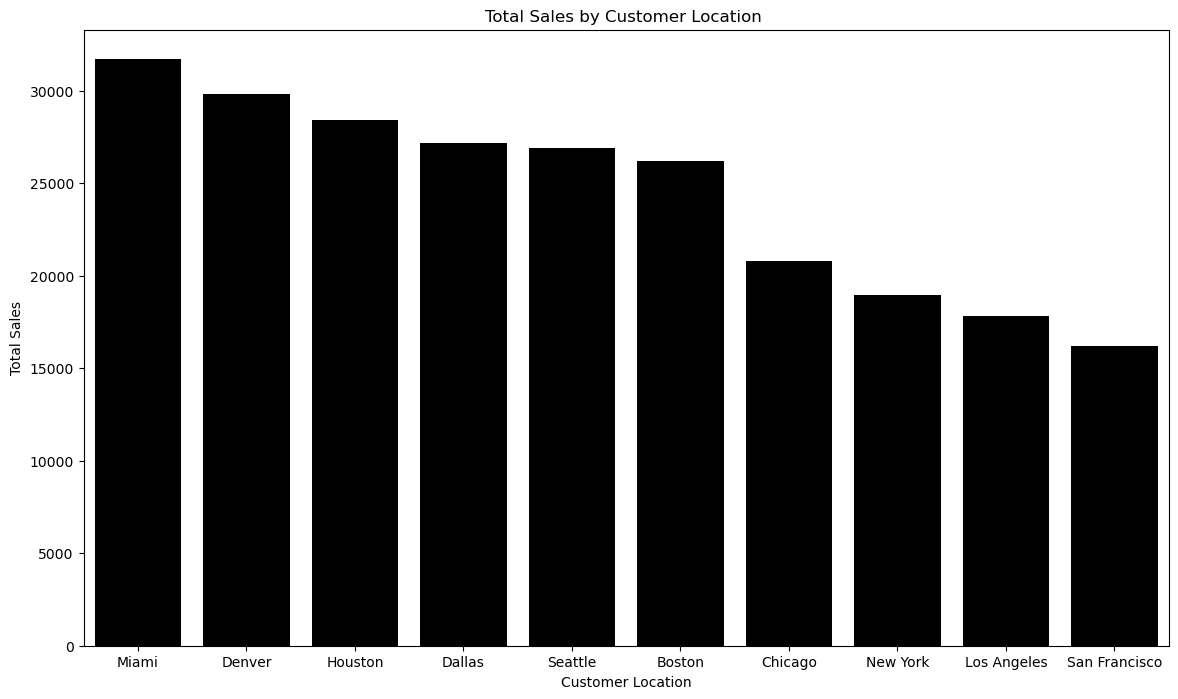

In [174]:

plt.figure(figsize=(14,8))
sns.barplot(x=grouped_location.index,y=grouped_location.values,color='Black')
plt.title('Total Sales by Customer Location ')
plt.xlabel('Customer Location')
plt.ylabel('Total Sales')
plt.show()

In [103]:
grouped_product = df.groupby("Product")["Quantity"].sum().sort_values(ascending = False)

In [104]:
print(grouped_product)

Product
Smartwatch         105
Smartphone          97
Headphones          73
Laptop              73
Running Shoes       72
Book                69
Refrigerator        65
Jeans               62
T-Shirt             53
Washing Machine     45
Name: Quantity, dtype: int64


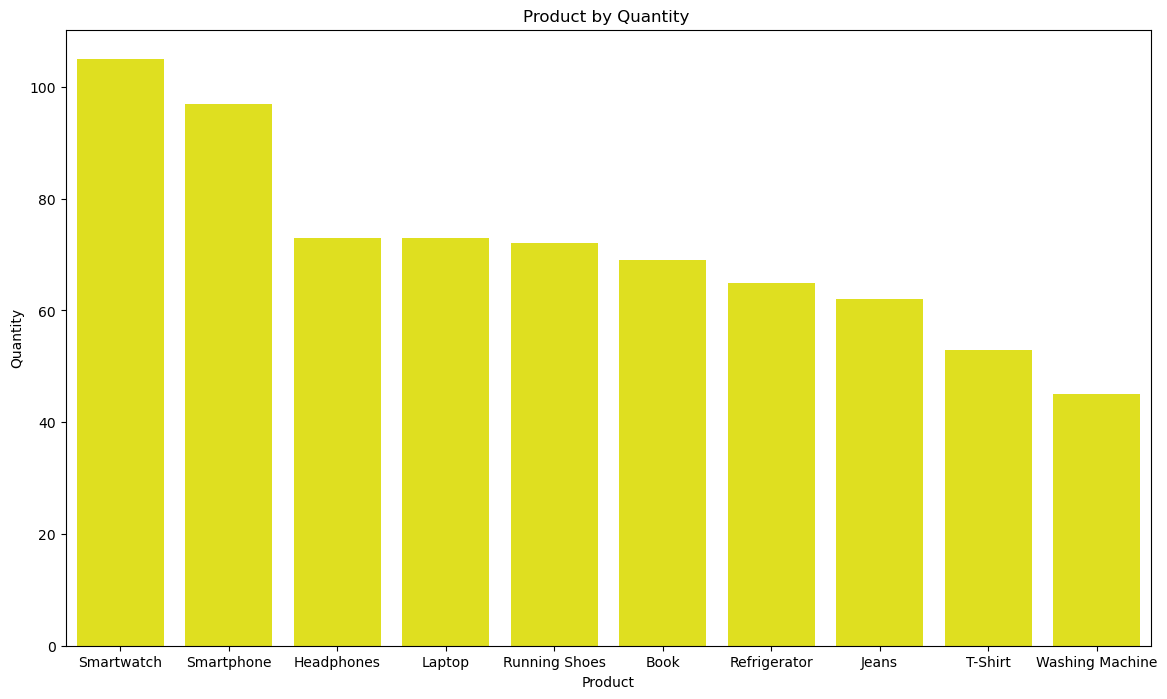

In [171]:
grouped_product
plt.figure(figsize=(14,8))
sns.barplot(x=grouped_product.index,y=grouped_product.values,color='Yellow')
plt.title('Product by Quantity ')
plt.xlabel('Product')
plt.ylabel('Quantity')
plt.show()
# Form this observation what we can conclude is that smartwatch is the most sold item
# and washing machine is the list sold item


In [106]:
# Categories wise analyis
total_sale_by_categories = df.groupby("Category")["Total Sales"].sum().sort_values(ascending = False)

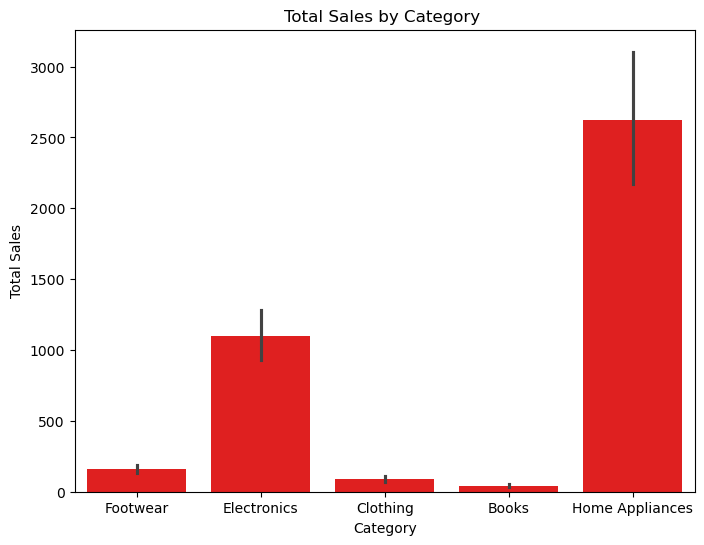

In [159]:
plt.figure(figsize=(8,6))
sns.barplot(x='Category',y='Total Sales',data=df,color='Red')
plt.title('Total Sales by Category ')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

In [108]:
print(total_sale_by_categories)

Category
Electronics        129950
Home Appliances    105000
Footwear             4320
Clothing             3540
Books                1035
Name: Total Sales, dtype: int64


In [109]:
total_unit_solds_by_categories = df.groupby("Category")["Quantity"].sum().sort_values(ascending = False)


In [110]:
print(total_unit_solds_by_categories)

Category
Electronics        348
Clothing           115
Home Appliances    110
Footwear            72
Books               69
Name: Quantity, dtype: int64


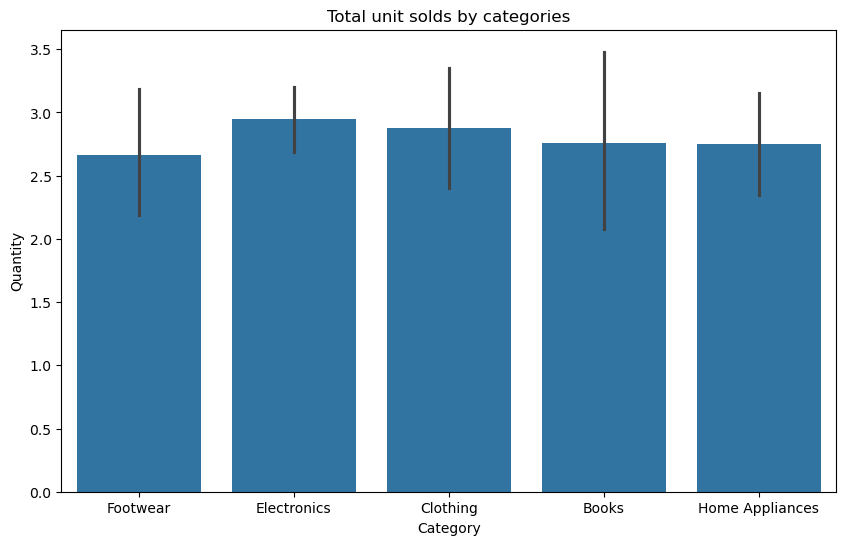

In [154]:
plt.figure(figsize=(10,6))
sns.barplot(x='Category',y='Quantity',data=df)
plt.title('Total unit solds by categories')
plt.xlabel('Category')
plt.ylabel('Quantity')
plt.show()

In [112]:
#Group by Multiple Columns
total_unit_solds_by_categoreis_per_location = df.groupby(["Category", "Customer Location"])["Quantity"].sum()

In [113]:
total_unit_solds_by_categoreis_per_location


Category         Customer Location
Books            Boston                8
                 Chicago              14
                 Dallas                5
                 Denver                5
                 Houston               2
                 Los Angeles           2
                 Miami                 8
                 New York              2
                 San Francisco        17
                 Seattle               6
Clothing         Boston               12
                 Chicago               9
                 Dallas               27
                 Denver               18
                 Houston               4
                 Los Angeles           2
                 Miami                 5
                 New York             24
                 San Francisco         4
                 Seattle              10
Electronics      Boston               35
                 Chicago              31
                 Dallas               23
                 Denve

In [114]:
sorted_data =  total_unit_solds_by_categoreis_per_location.groupby(level=0,group_keys = False).apply(lambda x:x.sort_values(ascending = False))
# Level  =0 means group by the first level of the index(that is category in this case)

In [115]:
print(sorted_data)

Category         Customer Location
Books            San Francisco        17
                 Chicago              14
                 Boston                8
                 Miami                 8
                 Seattle               6
                 Dallas                5
                 Denver                5
                 Houston               2
                 Los Angeles           2
                 New York              2
Clothing         Dallas               27
                 New York             24
                 Denver               18
                 Boston               12
                 Seattle              10
                 Chicago               9
                 Miami                 5
                 Houston               4
                 San Francisco         4
                 Los Angeles           2
Electronics      Houston              58
                 Miami                48
                 Boston               35
                 New Y

In [116]:
#Applying Multiple Aggregations¶
aggreastions = df.groupby("Category")["Total Sales"].agg(["sum","mean","max","min"]).sort_values(ascending = False, by = "sum")


In [117]:
aggreastions


,sum,mean,max,min
Category,,,,
Electronics,129950,1101.271186,4000,100
Home Appliances,105000,2625.000000,6000,600
Footwear,4320,160.000000,300,60
Clothing,3540,88.500000,200,20
Books,1035,41.400000,75,15


In [118]:
# Month wise Sales
Day_wise_sales = df.groupby("Day")["Total Sales"].sum().sort_values(ascending = False)

In [86]:
Day_wise_sales


Day
Monday       42975
Tuesday      42650
Thursday     40815
Sunday       38135
Friday       32715
Wednesday    26930
Saturday     19625
Name: Total Sales, dtype: int64

In [87]:
#Analysis of Customer Behaviour
# R - Recency (How recently a customer made a purchase)
# F - Frequency (How often a customer makes a purchase)
# M - Monetary (How much money a customer has spent in total)
# RFM analysis is done to find best customers (rescent, frequent and high spenders)
# To segment the customers (like loyal , dormant)
